In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src3'))

In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image

from utils import save, load
from process_outputs_fast import app, crop, resize_for_segmentation, segment, downsample, center_of_mass, make_overhead, process_outputs, warmup, DEFAULT_PROMPT, MAX_SIDE

In [3]:
# Start Modal app — keep alive for the whole session
_app_ctx = app.run.aio()
await _app_ctx.__aenter__()

In [4]:
BASE_DIR = Path('/home/ethantu/workspace/good-vibrations/data')
sample_id, output_id = '000006', '000000'

output_dir = BASE_DIR / f'outputs/{output_id}'
sample_dir = BASE_DIR / f'samples/{sample_id}'
raw_overhead_path = output_dir / '00_raw_overhead.png'
speaker = '0001'

## Step 1 — Profile where the 3-4s goes

Run `process_outputs` with detailed timing. The output will show a breakdown:
- **local serialize**: time to convert PIL → numpy before sending
- **Modal round-trip total**: everything from `.aio()` call to result back
  - **network+serialization overhead**: round-trip minus remote compute
  - **set_image (ViT encoder)**: the image encoder forward pass — usually the biggest chunk
  - **set_text_prompt (decode)**: text encoding + mask decoder
  - **postprocess**: argmax / mask selection

Run twice: first call may still encode the text prompt (cache miss), second will be a cache hit.

[000006] Process Output 000000
[000006] Box is not empty
[000006] overwriting previous run
[000006] crop+resize (256, 228): 0.054s
[segment timing]
  local serialize:   0.1ms
  Modal round-trip:  27599.0ms total
    └ network+serial overhead: ~26376.6ms
    └ set_image (ViT encoder): 407.9ms
    └ set_text_prompt (decode): 804.8ms
    └ postprocess:             9.5ms
[000006] segment TOTAL: 27.600s
[000006] downsample: 0.001s
[000006] center of mass: 0.000s
[000006] make overhead: 0.017s
[000006] ===== TOTAL: 27.673s =====


/home/ethantu/workspace/good-vibrations/src3/process_outputs_fast.py:188: RuntimeWarning: Mean of empty slice
  downsampled_mask = np.nanmean(arr.reshape(out_h, H2 // out_h, out_w, W2 // out_w), axis=(1, 3))
/home/ethantu/workspace/good-vibrations/src3/process_outputs_fast.py:189: RuntimeWarning: invalid value encountered in cast
  return Image.fromarray((downsampled_mask * 255).astype(np.uint8), mode="L")


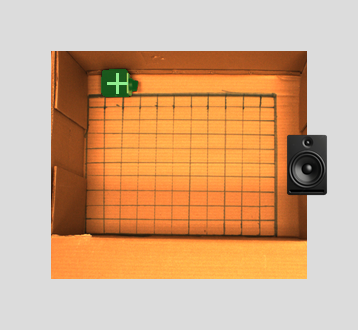

In [5]:
# First call — text prompt encoded fresh, image encoded fresh
overhead = await process_outputs(speaker, raw_overhead_path, output_dir, sample_dir)
overhead

[000006] Process Output 000000
[000006] Box is not empty
[000006] overwriting previous run
[000006] crop+resize (256, 228): 0.049s
[segment timing]
  local serialize:   0.1ms
  Modal round-trip:  1512.9ms total
    └ network+serial overhead: ~1326.5ms
    └ set_image (ViT encoder): 25.0ms
    └ set_text_prompt (decode): 161.1ms
    └ postprocess:             0.1ms
[000006] segment TOTAL: 1.514s
[000006] downsample: 0.001s
[000006] center of mass: 0.000s
[000006] make overhead: 0.017s
[000006] ===== TOTAL: 1.581s =====


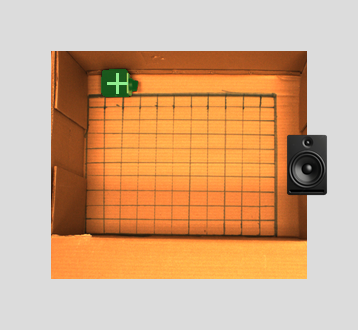

In [6]:
# Second call — text prompt should now be cached on the remote container
# Compare set_text_prompt time vs first call
overhead = await process_outputs(speaker, raw_overhead_path, output_dir, sample_dir)
overhead

## Step 2 — Isolate just the segment call

Crop once, then call `segment()` in a tight loop to measure steady-state latency and see if text caching helps.

In [ ]:
import time

cropped = resize_for_segmentation(crop(load(raw_overhead_path), 0.15, 0.67, 0.08, 0.7))
print(f'Resized image: {cropped.size}  (W x H, max_side={MAX_SIDE})')

for i in range(3):
    print(f'\n--- call {i+1} ---')
    t0 = time.perf_counter()
    mask = await segment(cropped, DEFAULT_PROMPT, is_empty_box=False, print_timing=True)
    print(f'wall time: {time.perf_counter()-t0:.3f}s')

## Step 3 — Does image size matter? Try downscaling before sending

SAM3's ViT encoder resizes the image internally anyway (typically to 1024px). Sending a smaller image reduces serialization bytes AND potentially lets the model resize faster. Check whether quality is acceptable.


--- max_side=1024  size=(256, 228)  payload=171KB ---
[segment timing]
  local serialize:   0.1ms
  Modal round-trip:  1165.6ms total
    └ network+serial overhead: ~981.3ms
    └ set_image (ViT encoder): 21.2ms
    └ set_text_prompt (decode): 162.8ms
    └ postprocess:             0.1ms
wall time: 1.166s


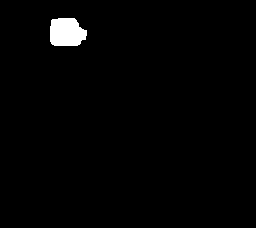


--- max_side=512  size=(256, 228)  payload=171KB ---
[segment timing]
  local serialize:   0.1ms
  Modal round-trip:  857.1ms total
    └ network+serial overhead: ~673.6ms
    └ set_image (ViT encoder): 21.2ms
    └ set_text_prompt (decode): 162.1ms
    └ postprocess:             0.1ms
wall time: 0.857s


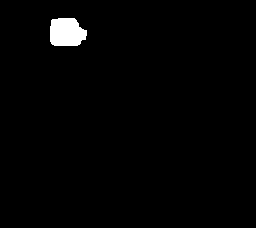


--- max_side=256  size=(256, 228)  payload=171KB ---
[segment timing]
  local serialize:   0.1ms
  Modal round-trip:  859.8ms total
    └ network+serial overhead: ~675.5ms
    └ set_image (ViT encoder): 21.4ms
    └ set_text_prompt (decode): 162.7ms
    └ postprocess:             0.1ms
wall time: 0.860s


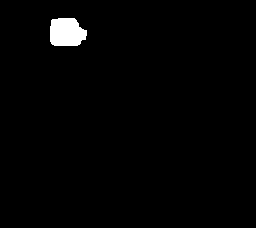

In [8]:
import time

for max_side in [1024, 512, 256]:
    resized = cropped.copy()
    if max(resized.size) > max_side:
        scale = max_side / max(resized.size)
        new_size = (int(resized.width * scale), int(resized.height * scale))
        resized = resized.resize(new_size, Image.LANCZOS)

    arr = np.array(resized.convert('RGB'), dtype=np.uint8)
    kb = arr.nbytes / 1024
    print(f'\n--- max_side={max_side}  size={resized.size}  payload={kb:.0f}KB ---')
    t0 = time.perf_counter()
    mask = await segment(resized, DEFAULT_PROMPT, is_empty_box=False, print_timing=True)
    print(f'wall time: {time.perf_counter()-t0:.3f}s')
    display(mask)

## Step 4 — Warmup: pre-encode the prompt right after model load

Call `warmup()` immediately after the app starts. This forces text encoding to happen during the warm-up phase rather than on the first real call.

In [9]:
# If you restart the kernel, run this right after `await _app_ctx.__aenter__()`
# to pre-encode the prompt so the first real call is fully warm.
await warmup(DEFAULT_PROMPT)

[warmup] pre-encoding prompt on remote container...
[warmup] done in 0.32s


## Summary — reading the timing output

Once you run the cells above, look for which line dominates:

| What dominates | Fix |
|---|---|
| `set_image` >> everything else | Image encoder is the bottleneck — try smaller input (Step 3), or accept it as SAM3's fixed cost |
| `set_text_prompt` large on 1st call, small on 2nd | Text caching is working — make sure `warmup()` is called after model load |
| `network+serial overhead` >> remote compute | Payload too large — downscale before sending (Step 3) |
| All roughly equal and ~1s each | Irreducible cost for this model/GPU — would need a smaller model or a bigger GPU |

## Step 5 — Full pipeline at 256px

Run `process_outputs` end-to-end with the resize baked in. Expect ~0.6s for the segment call and ~1s total.

[000006] Process Output 000000
[000006] Box is not empty
[000006] overwriting previous run
[000006] crop+resize (256, 228): 0.048s
[segment timing]
  local serialize:   0.1ms
  Modal round-trip:  861.8ms total
    └ network+serial overhead: ~677.3ms
    └ set_image (ViT encoder): 21.4ms
    └ set_text_prompt (decode): 162.9ms
    └ postprocess:             0.1ms
[000006] segment TOTAL: 0.863s
[000006] downsample: 0.001s
[000006] center of mass: 0.000s
[000006] make overhead: 0.017s
[000006] ===== TOTAL: 0.930s =====


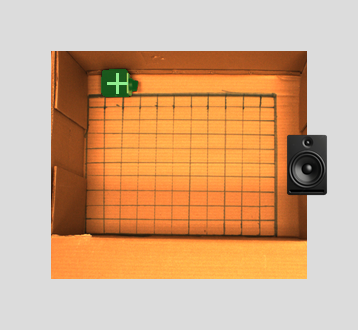

In [10]:
overhead = await process_outputs(speaker, raw_overhead_path, output_dir, sample_dir)
overhead